# Caesar Infusion Sweep Analyzer

This notebook analyzes results from the Caesar infusion sweep experiments.
It can be run while the sweep is in progress to monitor results.

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Load Sweep Results from Wandb

In [2]:
# Initialize wandb API
api = wandb.Api()

# Load all runs from the sweep project
ENTITY = "jrosseruk"  # Your wandb entity/username
PROJECT = "caesar-infusion-sweep-v3"  # Updated to v3

runs = api.runs(f"{ENTITY}/{PROJECT}")
print(f"Found {len(runs)} runs in {ENTITY}/{PROJECT}")

Found 80 runs in jrosseruk/caesar-infusion-sweep-v3


In [3]:
# Since runs are "running", summary may not be synced yet
# Try fetching history instead which contains logged metrics
print(f"Total runs found: {len(runs)}")

data = []
for run in runs:
    print(f"\nProcessing {run.name} (state: {run.state})...")
    
    try:
        # Fetch history - this contains all wandb.log() calls
        history = run.history()
        print(f"  History rows: {len(history)}")
        
        if len(history) == 0:
            print("  No logged data yet")
            continue
        
        # Each row in history is one wandb.log() call (one experiment)
        for idx, row in history.iterrows():
            if 'targeting_score' not in row or pd.isna(row.get('targeting_score')):
                continue
                
            data.append({
                'targeting_score': row.get('targeting_score'),
                'delta_ce_correct': row.get('delta_ce_correct'),
                'delta_ce_target': row.get('delta_ce_target'),
                'delta_ce_other': row.get('delta_ce_other'),
                'margin_shift_target': row.get('margin_shift_target'),
                'margin_shift_correct': row.get('margin_shift_correct'),
                'final_retrain_train_loss': row.get('final_retrain_train_loss'),
                'final_retrain_val_loss': row.get('final_retrain_val_loss'),
                'top_k': row.get('top_k'),
                'top_k_mode': row.get('top_k_mode'),
                'epsilon': row.get('epsilon'),
                'alpha': row.get('alpha'),
                'n_steps': row.get('n_steps'),
                'n_probes': row.get('n_probes'),
                'probe_shift': row.get('probe_shift'),
                'target_shift': row.get('target_shift'),
                'noise_std': row.get('noise_std'),
                'elapsed_seconds': row.get('elapsed_seconds'),
                'config_seed': row.get('config_seed'),
                'run_id': run.id,
                'run_name': run.name,
                'worker_id': run.name.split('_')[1] if '_' in run.name else None,
            })
        print(f"  Found {len([r for r in data if r.get('run_id') == run.id])} experiments with targeting_score")
        
    except Exception as e:
        print(f"  Error: {e}")
        continue

df = pd.DataFrame(data)
print(f"\n{'='*60}")
print(f"Loaded {len(df)} completed experiments from {len(runs)} workers")
if len(df) > 0:
    display(df.head(10))

Total runs found: 80

Processing worker_01_20260107_170942 (state: running)...
  History rows: 0
  No logged data yet

Processing worker_40_20260107_170942 (state: running)...
  History rows: 0
  No logged data yet

Processing worker_78_20260107_170942 (state: running)...
  History rows: 1
  Found 1 experiments with targeting_score

Processing worker_06_20260107_170942 (state: running)...
  History rows: 0
  No logged data yet

Processing worker_42_20260107_170942 (state: running)...
  History rows: 0
  No logged data yet

Processing worker_41_20260107_170942 (state: running)...
  History rows: 0
  No logged data yet

Processing worker_07_20260107_170942 (state: running)...
  History rows: 0
  No logged data yet

Processing worker_04_20260107_170942 (state: running)...
  History rows: 0
  No logged data yet

Processing worker_00_20260107_170942 (state: running)...
  History rows: 0
  No logged data yet

Processing worker_19_20260107_170942 (state: running)...
  History rows: 0
  No log

,targeting_score,delta_ce_correct,delta_ce_target,delta_ce_other,margin_shift_target,margin_shift_correct,final_retrain_train_loss,final_retrain_val_loss,top_k,top_k_mode,...,n_steps,n_probes,probe_shift,target_shift,noise_std,elapsed_seconds,config_seed,run_id,run_name,worker_id
0,0.680550,0.052630,-2.781331,-2.100780,2.768346,0,0.576608,0.549626,100,absolute,...,10,1000,2,0,0.0,144.068755,780000,5iaj50zw,worker_78_20260107_170942,78
1,-0.059525,0.000503,-0.055204,-0.114730,0.055708,0,0.896390,0.677042,50,positive,...,50,1,19,8,0.5,126.495074,260000,bauw6n5v,worker_26_20260107_170942,26
2,0.305981,0.008936,-0.149412,0.156569,0.158348,0,0.891213,0.677034,50,negative,...,50,10,15,18,0.5,135.369418,120000,d4ydei7u,worker_12_20260107_170942,12
3,0.997831,0.020647,-1.772259,-0.774429,1.792907,0,0.570015,0.549531,50,negative,...,50,10,13,21,0.0,141.525599,320000,jbrvtgyl,worker_32_20260107_170942,32
4,0.112179,-0.000645,-0.117484,-0.005305,0.116839,0,1.126057,0.894097,100,positive,...,10,1,3,20,1.0,81.642100,340000,tzg5ghkd,worker_34_20260107_170942,34
5,0.019008,0.027331,-0.036680,-0.017672,0.068725,0,0.899669,0.676813,50,absolute,...,10,1000,21,3,0.5,114.945953,150000,500k2rco,worker_15_20260107_170942,15
6,0.024946,0.056765,-0.084236,-0.059291,0.144791,0,0.908258,0.677185,100,negative,...,10,100,15,8,0.5,104.646860,350000,co7kyjy9,worker_35_20260107_170942,35
7,0.092240,0.002308,-0.100112,-0.007873,0.103389,0,0.890572,0.676849,50,negative,...,10,1000,1,24,0.5,109.852914,730000,h2e0v26k,worker_73_20260107_170942,73
8,0.000686,-0.000017,-0.000931,-0.000245,0.000987,0,0.560446,0.549505,50,absolute,...,10,1000,3,8,0.0,109.540488,500000,zimq55uw,worker_50_20260107_170942,50
9,0.296269,0.004448,-0.462598,-0.166329,0.470923,0,0.563664,0.549520,50,negative,...,50,100,24,25,0.0,152.933100,300000,9guxiwe4,worker_30_20260107_170942,30


## 2. Summary Statistics

In [4]:
# Overall statistics
print("=" * 50)
print("Overall Targeting Score Statistics")
print("=" * 50)
print(df['targeting_score'].describe())
print(f"\nPositive targeting (good): {(df['targeting_score'] > 0).sum()} / {len(df)} ({100 * (df['targeting_score'] > 0).mean():.1f}%)")

Overall Targeting Score Statistics
count    20.000000
mean      0.244425
std       0.315871
min      -0.059525
25%       0.017020
50%       0.102209
75%       0.342987
max       0.997831
Name: targeting_score, dtype: float64

Positive targeting (good): 19 / 20 (95.0%)


In [5]:
# Best experiments
print("\nTop 10 Experiments by Targeting Score:")
top_cols = ['targeting_score', 'delta_ce_target', 'delta_ce_other', 
            'top_k', 'epsilon', 'alpha', 'n_steps', 'probe_shift', 'target_shift', 'noise_std']
df.nlargest(10, 'targeting_score')[top_cols]


Top 10 Experiments by Targeting Score:


,targeting_score,delta_ce_target,delta_ce_other,top_k,epsilon,alpha,n_steps,probe_shift,target_shift,noise_std
3,0.997831,-1.772259,-0.774429,50,1,0.100,50,13,21,0.0
14,0.966615,-1.123715,-0.157100,100,100,0.100,10,23,3,0.0
0,0.680550,-2.781331,-2.100780,100,1,0.010,10,2,0,0.0
10,0.427215,-0.402914,0.024301,200,100,0.010,10,1,16,1.0
11,0.414419,-0.649029,-0.234610,100,1,0.001,10,15,19,0.0
18,0.319176,-0.805487,-0.486311,100,10,0.001,10,15,13,0.0
2,0.305981,-0.149412,0.156569,50,1,0.001,50,15,18,0.5
9,0.296269,-0.462598,-0.166329,50,1,0.001,50,24,25,0.0
12,0.165755,-0.167198,-0.001443,100,100,0.100,10,3,10,0.5
4,0.112179,-0.117484,-0.005305,100,1,0.010,10,3,20,1.0


## 3. Targeting Score Distribution

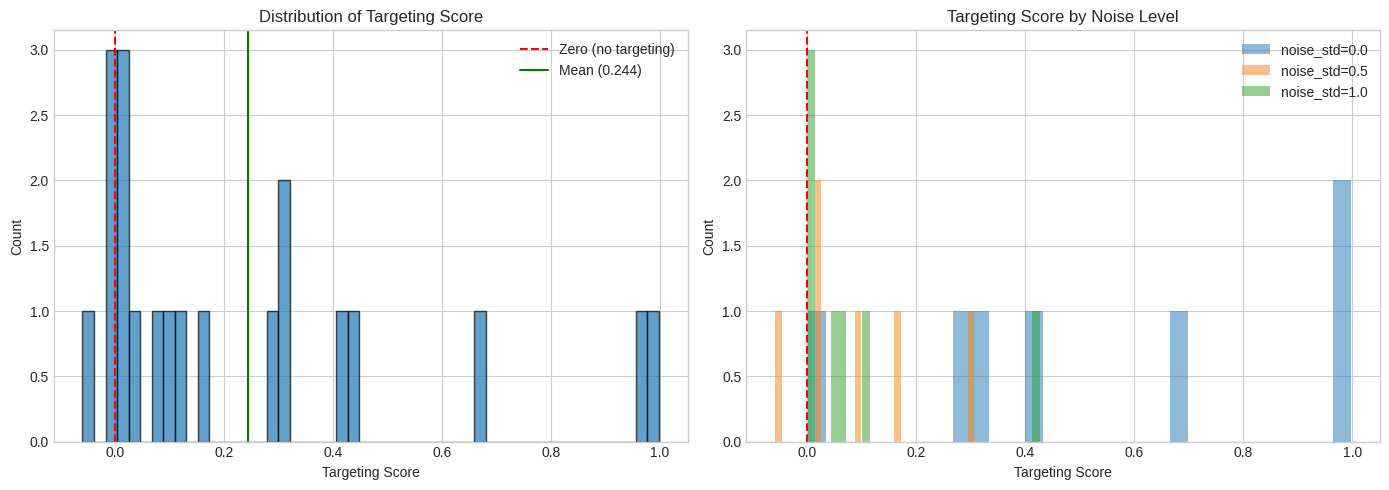

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(df['targeting_score'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', label='Zero (no targeting)')
ax.axvline(df['targeting_score'].mean(), color='green', linestyle='-', label=f'Mean ({df["targeting_score"].mean():.3f})')
ax.set_xlabel('Targeting Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Targeting Score')
ax.legend()

# By noise_std
ax = axes[1]
for noise_std in sorted(df['noise_std'].unique()):
    subset = df[df['noise_std'] == noise_std]
    ax.hist(subset['targeting_score'], bins=30, alpha=0.5, label=f'noise_std={noise_std}')
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Targeting Score')
ax.set_ylabel('Count')
ax.set_title('Targeting Score by Noise Level')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Hyperparameter Analysis

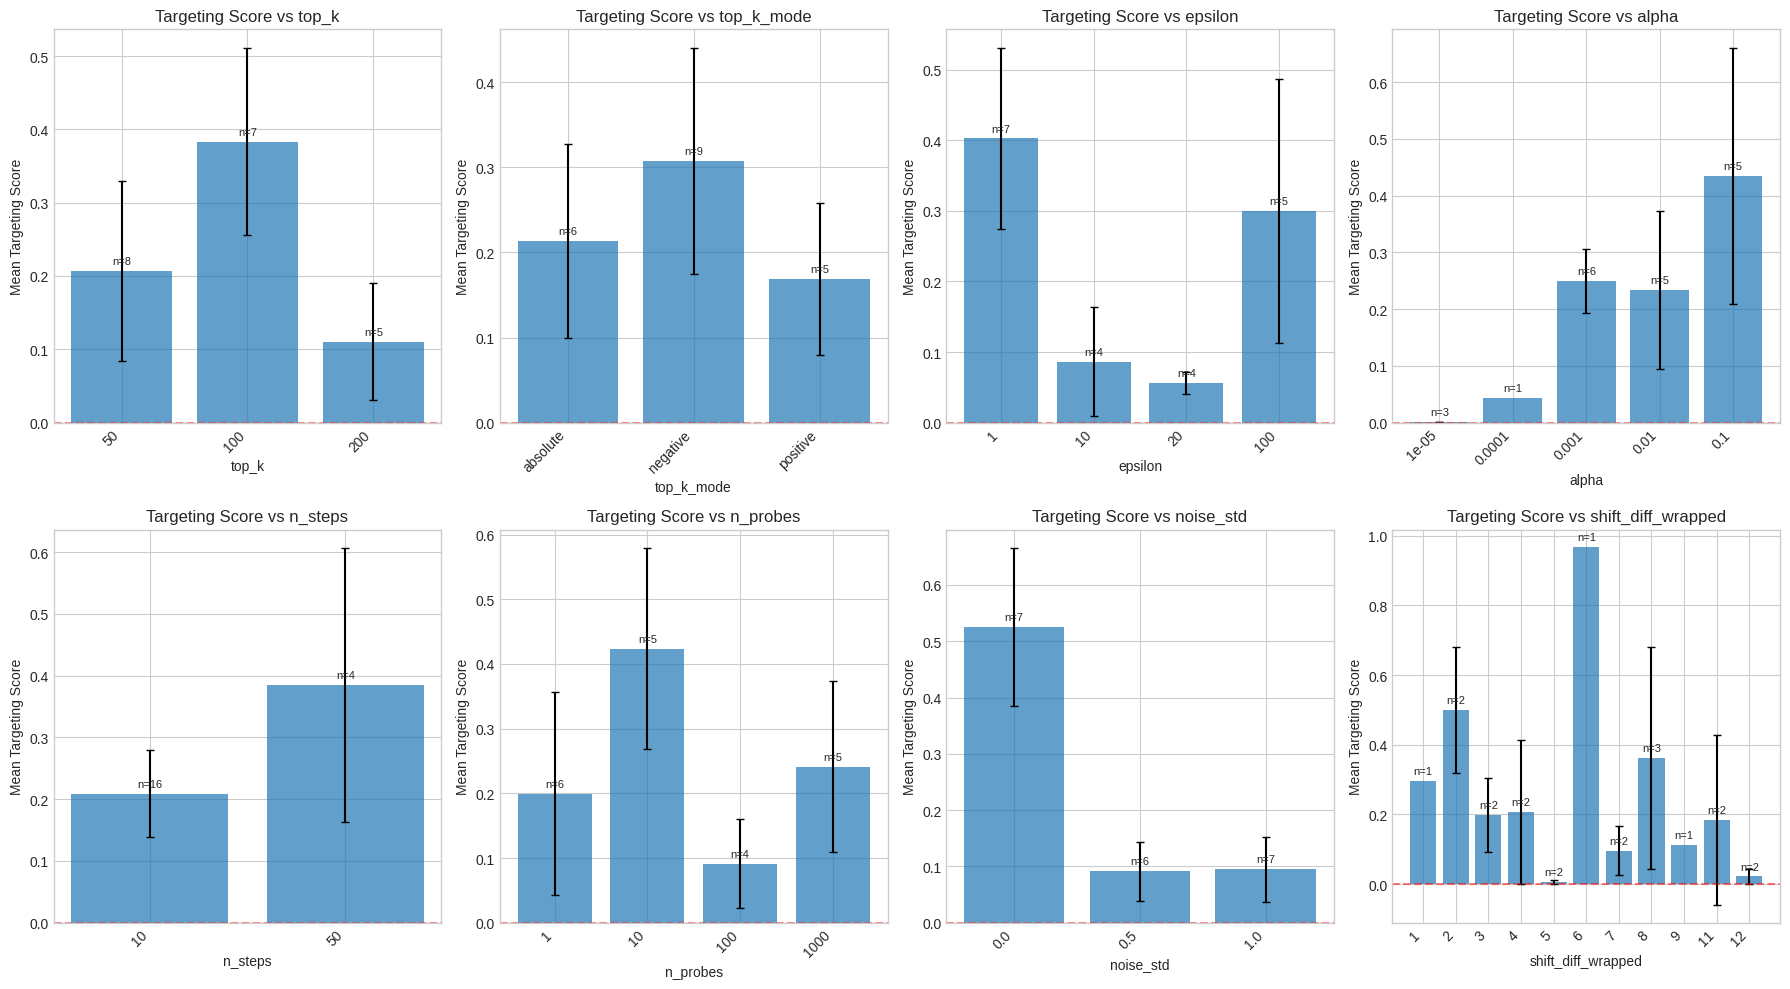

In [7]:
# Targeting score vs key hyperparameters
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

hp_params = ['top_k', 'top_k_mode', 'epsilon', 'alpha', 'n_steps', 'n_probes', 'noise_std', 'shift_diff_wrapped']

# Compute shift difference if not already present
if 'shift_diff' not in df.columns:
    df['shift_diff'] = abs(df['target_shift'] - df['probe_shift'])
    df['shift_diff_wrapped'] = df['shift_diff'].apply(lambda x: min(x, 26 - x))

for ax, param in zip(axes.flat, hp_params):
    if param in df.columns and df[param].notna().any():
        # Group by parameter value
        grouped = df.groupby(param)['targeting_score'].agg(['mean', 'std', 'count'])
        
        # Bar plot with error bars
        x = range(len(grouped))
        ax.bar(x, grouped['mean'], yerr=grouped['std'] / np.sqrt(grouped['count']),
               capsize=3, alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in grouped.index], rotation=45, ha='right')
        ax.axhline(0, color='red', linestyle='--', alpha=0.5)
        ax.set_xlabel(param)
        ax.set_ylabel('Mean Targeting Score')
        ax.set_title(f'Targeting Score vs {param}')
        
        # Add count annotations
        for i, (idx, row) in enumerate(grouped.iterrows()):
            ax.annotate(f'n={int(row["count"])}', (i, row['mean']), 
                       textcoords='offset points', xytext=(0, 5), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

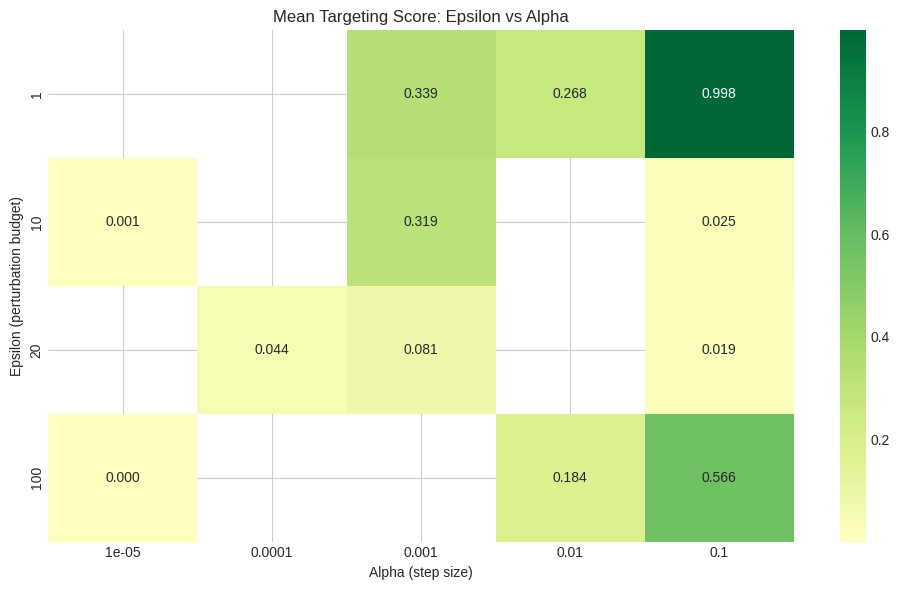

In [8]:
# Heatmap: epsilon vs alpha
if 'epsilon' in df.columns and 'alpha' in df.columns:
    pivot = df.pivot_table(values='targeting_score', index='epsilon', columns='alpha', aggfunc='mean')
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0)
    plt.title('Mean Targeting Score: Epsilon vs Alpha')
    plt.xlabel('Alpha (step size)')
    plt.ylabel('Epsilon (perturbation budget)')
    plt.tight_layout()
    plt.show()

## 5. Shift Analysis

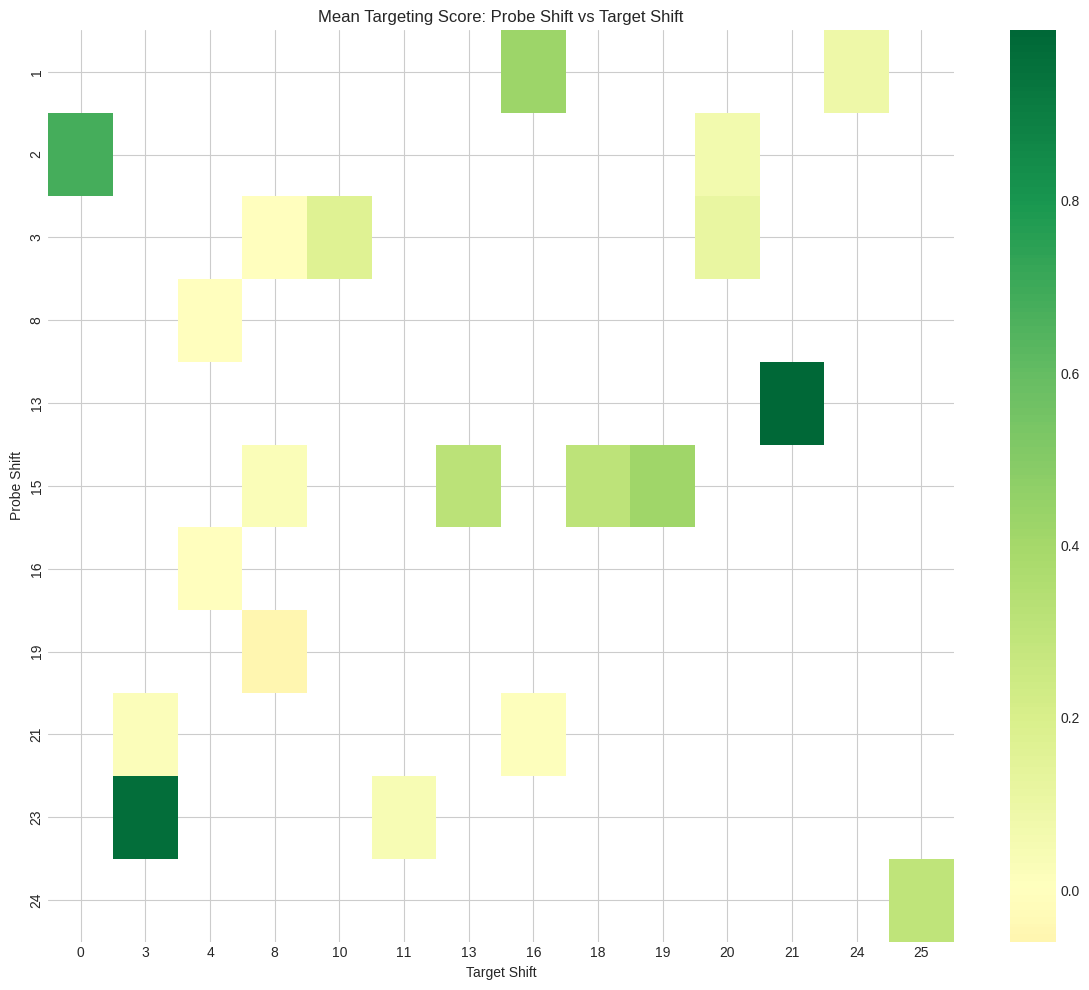

In [9]:
# Heatmap: probe_shift vs target_shift
if 'probe_shift' in df.columns and 'target_shift' in df.columns:
    pivot = df.pivot_table(values='targeting_score', index='probe_shift', 
                          columns='target_shift', aggfunc='mean')
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(pivot, annot=False, cmap='RdYlGn', center=0)
    plt.title('Mean Targeting Score: Probe Shift vs Target Shift')
    plt.xlabel('Target Shift')
    plt.ylabel('Probe Shift')
    plt.tight_layout()
    plt.show()

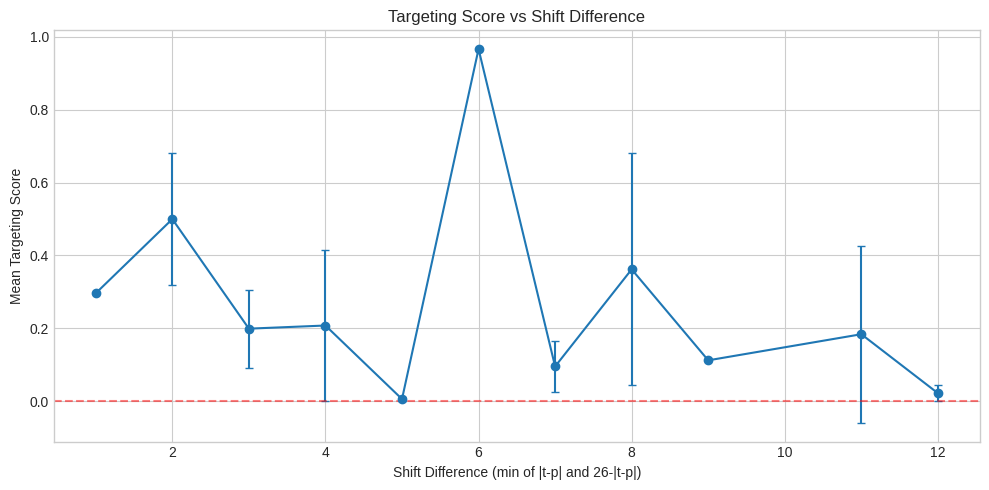

In [10]:
# Effect of shift difference
df['shift_diff'] = abs(df['target_shift'] - df['probe_shift'])
df['shift_diff_wrapped'] = df['shift_diff'].apply(lambda x: min(x, 26 - x))

plt.figure(figsize=(10, 5))
grouped = df.groupby('shift_diff_wrapped')['targeting_score'].agg(['mean', 'std', 'count'])
plt.errorbar(grouped.index, grouped['mean'], yerr=grouped['std'] / np.sqrt(grouped['count']),
            marker='o', capsize=3)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Shift Difference (min of |t-p| and 26-|t-p|)')
plt.ylabel('Mean Targeting Score')
plt.title('Targeting Score vs Shift Difference')
plt.tight_layout()
plt.show()

## 6. CE Change Analysis

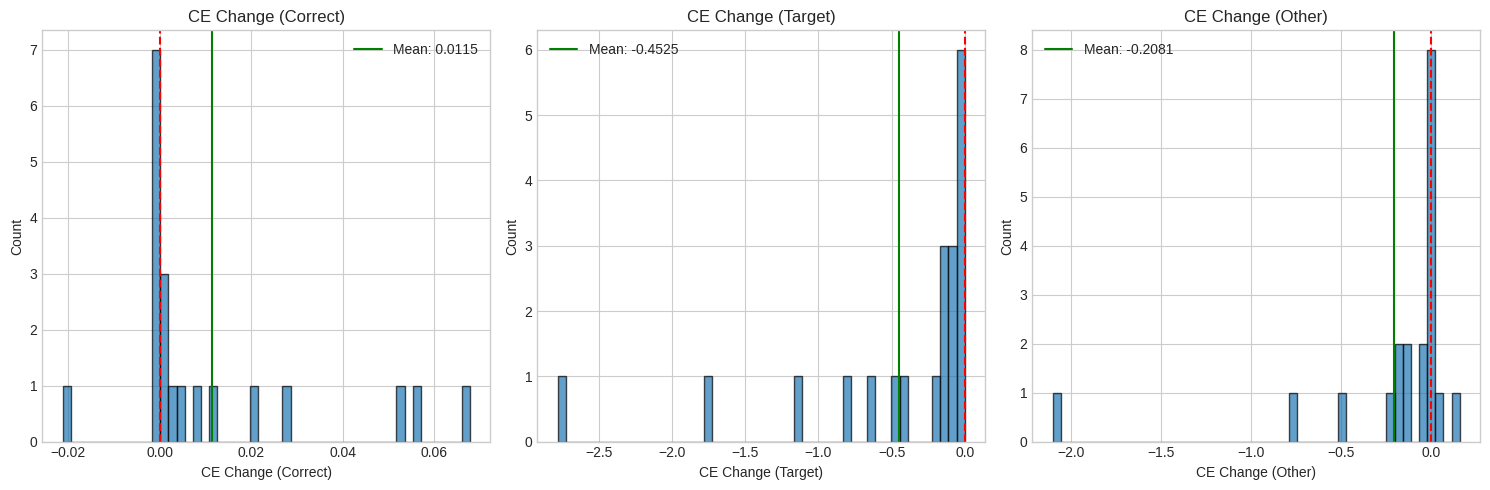

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes, 
                          ['delta_ce_correct', 'delta_ce_target', 'delta_ce_other'],
                          ['CE Change (Correct)', 'CE Change (Target)', 'CE Change (Other)']):
    if col in df.columns:
        ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7)
        ax.axvline(0, color='red', linestyle='--')
        ax.axvline(df[col].mean(), color='green', linestyle='-', label=f'Mean: {df[col].mean():.4f}')
        ax.set_xlabel(title)
        ax.set_ylabel('Count')
        ax.set_title(title)
        ax.legend()

plt.tight_layout()
plt.show()

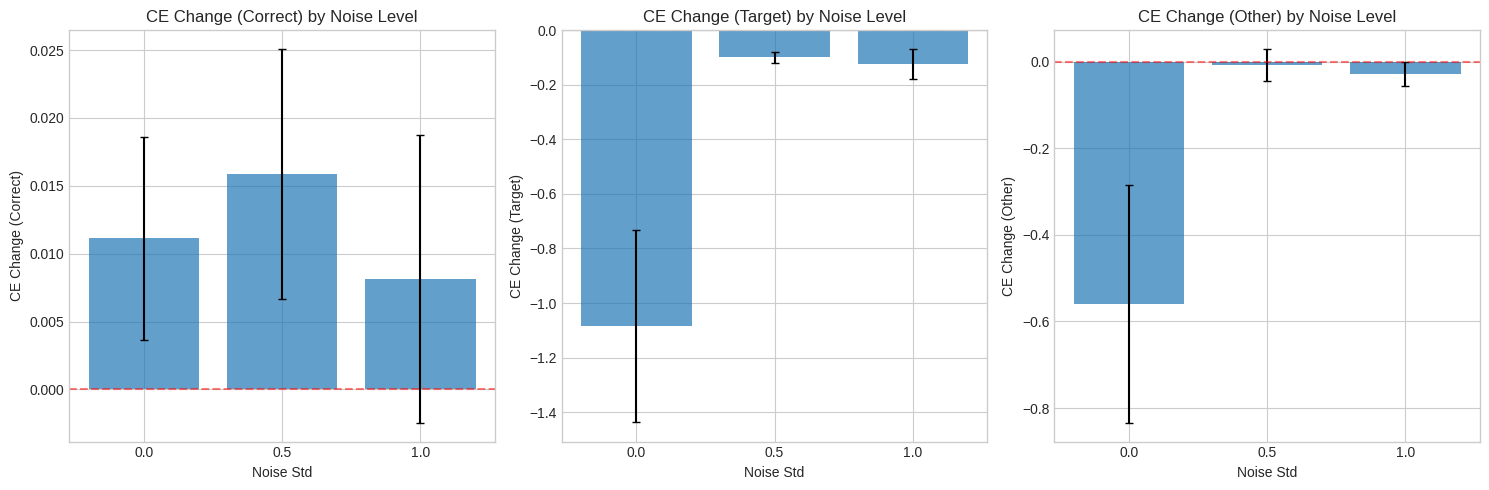

In [12]:
# CE changes by noise_std
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes,
                          ['delta_ce_correct', 'delta_ce_target', 'delta_ce_other'],
                          ['CE Change (Correct)', 'CE Change (Target)', 'CE Change (Other)']):
    if col in df.columns:
        grouped = df.groupby('noise_std')[col].agg(['mean', 'std', 'count'])
        x = range(len(grouped))
        ax.bar(x, grouped['mean'], yerr=grouped['std'] / np.sqrt(grouped['count']),
               capsize=3, alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in grouped.index])
        ax.axhline(0, color='red', linestyle='--', alpha=0.5)
        ax.set_xlabel('Noise Std')
        ax.set_ylabel(title)
        ax.set_title(f'{title} by Noise Level')

plt.tight_layout()
plt.show()

## 7. Progress Over Time

In [13]:
# Experiments over time
if 'created_at' in df.columns:
    df['created_at'] = pd.to_datetime(df['created_at'])
    df_sorted = df.sort_values('created_at')
    df_sorted['cumulative_count'] = range(1, len(df_sorted) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Cumulative experiments
    ax = axes[0]
    ax.plot(df_sorted['created_at'], df_sorted['cumulative_count'])
    ax.set_xlabel('Time')
    ax.set_ylabel('Cumulative Experiments')
    ax.set_title('Sweep Progress')
    plt.xticks(rotation=45)
    
    # Targeting score over time (running mean)
    ax = axes[1]
    window = min(50, len(df_sorted) // 10 + 1)
    df_sorted['targeting_score_rolling'] = df_sorted['targeting_score'].rolling(window=window).mean()
    ax.plot(df_sorted['created_at'], df_sorted['targeting_score_rolling'])
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Time')
    ax.set_ylabel(f'Targeting Score (rolling mean, window={window})')
    ax.set_title('Targeting Score Over Time')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

## 8. Worker Analysis

Worker Statistics:


,n_experiments,mean_targeting,std_targeting,mean_elapsed_s
worker_id,,,,
03,1,0.166,NaN,79.918
12,1,0.306,NaN,135.369
15,1,0.019,NaN,114.946
22,1,0.011,NaN,109.642
23,1,0.427,NaN,121.856
26,1,-0.060,NaN,126.495
28,1,0.414,NaN,142.702
30,1,0.296,NaN,152.933
32,1,0.998,NaN,141.526


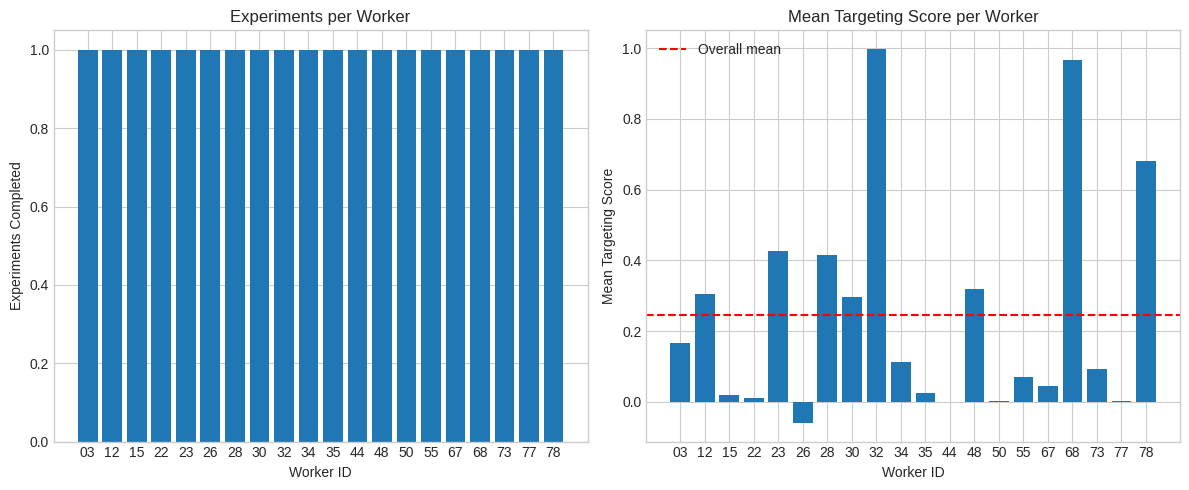

In [14]:
# Experiments per worker
if 'worker_id' in df.columns:
    worker_stats = df.groupby('worker_id').agg({
        'targeting_score': ['count', 'mean', 'std'],
        'elapsed_seconds': 'mean'
    }).round(3)
    worker_stats.columns = ['n_experiments', 'mean_targeting', 'std_targeting', 'mean_elapsed_s']
    
    print("Worker Statistics:")
    display(worker_stats)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Experiments per worker
    ax = axes[0]
    ax.bar(worker_stats.index, worker_stats['n_experiments'])
    ax.set_xlabel('Worker ID')
    ax.set_ylabel('Experiments Completed')
    ax.set_title('Experiments per Worker')
    
    # Mean targeting score per worker
    ax = axes[1]
    ax.bar(worker_stats.index, worker_stats['mean_targeting'],
           yerr=worker_stats['std_targeting'] / np.sqrt(worker_stats['n_experiments']),
           capsize=3)
    ax.axhline(df['targeting_score'].mean(), color='red', linestyle='--', label='Overall mean')
    ax.set_xlabel('Worker ID')
    ax.set_ylabel('Mean Targeting Score')
    ax.set_title('Mean Targeting Score per Worker')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

## 9. Export Results

In [15]:
# Save to CSV
output_path = 'sweep_results_summary.csv'
df.to_csv(output_path, index=False)
print(f"Saved {len(df)} experiments to {output_path}")

Saved 20 experiments to sweep_results_summary.csv


In [16]:
# Summary statistics for paper/report
print("\n" + "="*60)
print("SUMMARY FOR PAPER")
print("="*60)
print(f"Total experiments: {len(df)}")
print(f"Targeting score: {df['targeting_score'].mean():.4f} +/- {df['targeting_score'].std():.4f}")
print(f"Positive targeting rate: {100 * (df['targeting_score'] > 0).mean():.1f}%")
print(f"\nBest configuration:")
best = df.loc[df['targeting_score'].idxmax()]
print(f"  Targeting score: {best['targeting_score']:.4f}")
print(f"  top_k={best['top_k']}, epsilon={best['epsilon']}, alpha={best['alpha']}")
print(f"  n_steps={best['n_steps']}, n_probes={best['n_probes']}")
print(f"  probe_shift={best['probe_shift']}, target_shift={best['target_shift']}")
print(f"  noise_std={best['noise_std']}")


SUMMARY FOR PAPER
Total experiments: 20
Targeting score: 0.2444 +/- 0.3159
Positive targeting rate: 95.0%

Best configuration:
  Targeting score: 0.9978
  top_k=50, epsilon=1, alpha=0.1
  n_steps=50, n_probes=10
  probe_shift=13, target_shift=21
  noise_std=0.0


## 10. Load Best Experiment Visualization Data

Load the detailed visualization data from the best experiment to recreate diagnostic plots.

In [17]:
import torch
import json
import os
from pathlib import Path

# Centralized sweep results directory
SWEEP_RESULTS_DIR = Path('/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/caesar/sweep_results')
NOISE_STD_TARGET = 1.0  # Only consider experiments at this noise_std

def load_experiment(run_id):
    """Load config, metrics, and visualization data for an experiment."""
    base = SWEEP_RESULTS_DIR / run_id
    
    config = json.load(open(base / 'config.json'))
    metrics = json.load(open(base / 'metrics.json'))
    viz_data = torch.load(base / 'visualization_data.pt', weights_only=False)
    
    return config, metrics, viz_data

def find_best_experiment_for_noise(noise_std=0.5):
    """
    Find the experiment with highest targeting score for a given noise_std.
    """
    best_score = float('-inf')
    best_run_id = None

    for run_dir in SWEEP_RESULTS_DIR.iterdir():
        if not run_dir.is_dir():
            continue
        metrics_path = run_dir / 'metrics.json'
        config_path = run_dir / 'config.json'
        if not metrics_path.exists() or not config_path.exists():
            continue
        
        try:
            config = json.load(open(config_path))
            metrics = json.load(open(metrics_path))
            # May be float, int or str -- robust to storage type
            config_noise_std = float(config.get('noise_std', 'nan'))
            if config_noise_std != noise_std:
                continue
            score = metrics.get('targeting_score', float('-inf'))
            if score > best_score:
                best_score = score
                best_run_id = run_dir.name
        except Exception as e:
            print(f"Error reading {run_dir}: {e}")
            continue
    return best_run_id, best_score

# Check if results directory exists
if SWEEP_RESULTS_DIR.exists():
    run_dirs = list(SWEEP_RESULTS_DIR.iterdir())
    print(f"Found {len(run_dirs)} experiment results in sweep_results/")
    
    # Find and load best experiment for the specified noise_std
    best_run_id, best_score = find_best_experiment_for_noise(NOISE_STD_TARGET)
    
    if best_run_id:
        print(f"\nBest experiment at noise_std={NOISE_STD_TARGET}: {best_run_id}")
        print(f"Targeting score: {best_score:.4f}")
        
        config, metrics, viz_data = load_experiment(best_run_id)
        
        print(f"\nConfig:")
        for k, v in sorted(config.items()):
            print(f"  {k}: {v}")
        
        print(f"\nMetrics:")
        for k, v in sorted(metrics.items()):
            if isinstance(v, float):
                print(f"  {k}: {v:.4f}")
            else:
                print(f"  {k}: {v}")
        
        print(f"\nVisualization data keys: {list(viz_data.keys())}")
    else:
        print(f"No valid experiments found at noise_std={NOISE_STD_TARGET}!")
else:
    print(f"Sweep results directory not found: {SWEEP_RESULTS_DIR}")
    print("Run some experiments first, or check the path.")

Found 105 experiment results in sweep_results/

Best experiment at noise_std=1.0: w23_s230000_k200_mp_e100_a0.01_s10_p10_ps1_ts16_n1p0
Targeting score: 0.4272

Config:
  alpha: 0.01
  base_checkpoint_dir: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/caesar/caesar_noisy_checkpoints
  base_output_dir: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/caesar/caesar_noisy_infused_checkpoints
  batch_size: 64
  damping: 1e-08
  epoch_start: _9
  epoch_target: _10
  epsilon: 100
  learning_rate: 0.0003
  n_probes: 10
  n_steps: 10
  noise_std: 1.0
  probe_shift: 1
  random_seed: 42
  target_shift: 16
  top_k: 200
  top_k_mode: positive

Metrics:
  baseline_contrastive_mean: -2.3979
  delta_ce_correct: 0.0678
  delta_ce_other: 0.0243
  delta_ce_target: -0.4029
  final_contrastive_mean: -2.2263
  final_retrain_train_loss: 1.1342
  final_retrain_val_loss: 0.8943
  influence_score_max: 3835.2954
  influence_score_mean: 9.6962
  influence_score_min: -5463.9136
  influence_score_std: 274.0768
  margin_sh

## 11. Token-Level Margin Analysis

Visualize how the infusion affected token-level log probabilities for individual probes.

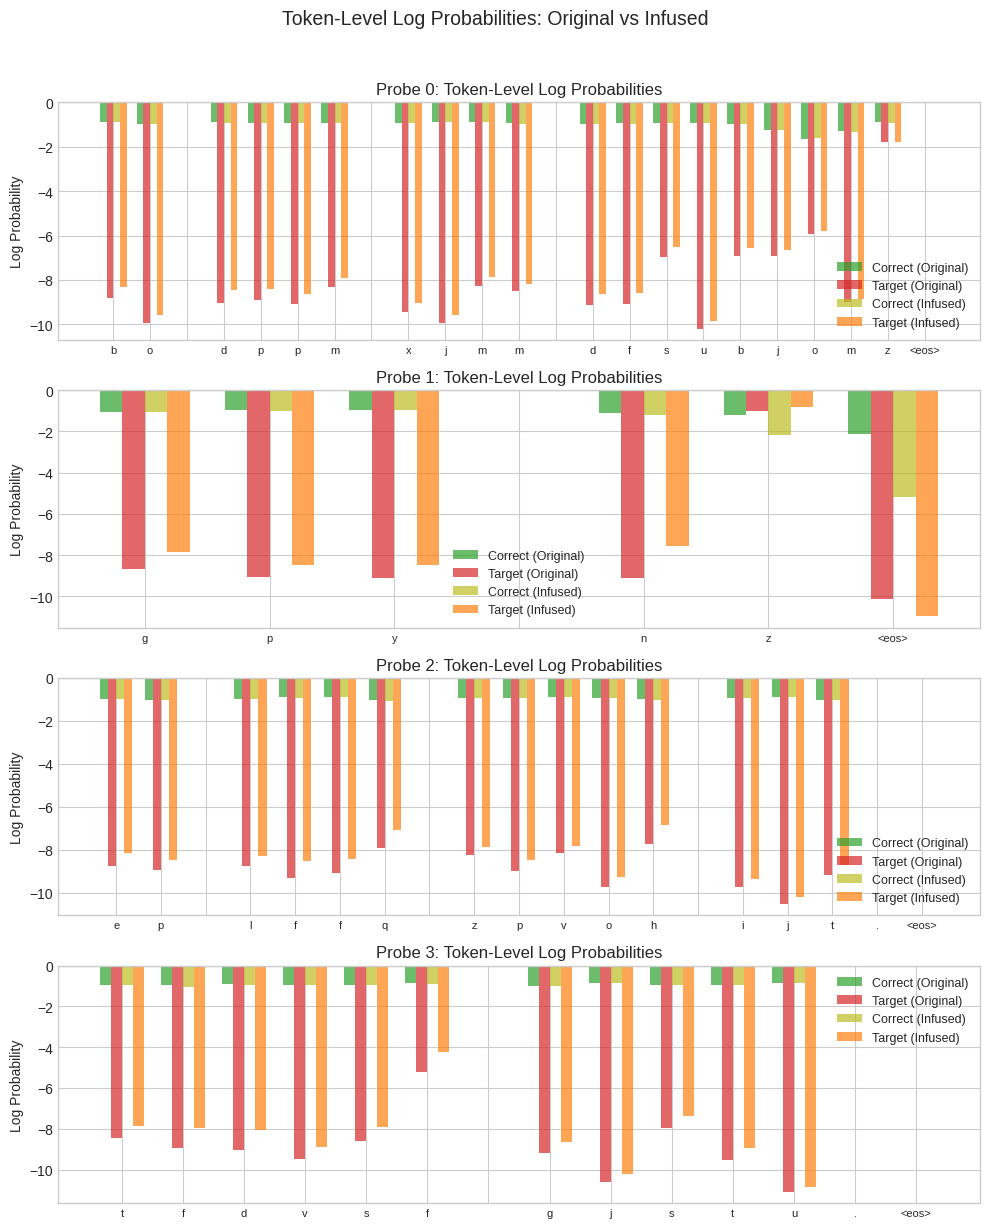

In [18]:
def plot_token_level_margins(token_level_data, n_probes=4):
    """Plot token-level log probs for original vs infused model: all 4 bars per xtick."""
    if not token_level_data:
        print("No token-level data available")
        return

    n_plots = min(n_probes, len(token_level_data))
    fig, axes = plt.subplots(n_plots, 1, figsize=(10, 3 * n_plots))
    if n_plots == 1:
        axes = [axes]  # make it iterable

    for i, probe_data in enumerate(token_level_data[:n_plots]):
        ax = axes[i]
        positions = np.arange(len(probe_data['correct_tokens']))
        width = 0.18

        # Four bars per position:
        ax.bar(positions - 1.5*width, probe_data['orig_correct_lp'], 
               width=width, label='Correct (Original)', alpha=0.7, color='tab:green')
        ax.bar(positions - 0.5*width, probe_data['orig_wrong_lp'], 
               width=width, label='Target (Original)', alpha=0.7, color='tab:red')
        ax.bar(positions + 0.5*width, probe_data['inf_correct_lp'], 
               width=width, label='Correct (Infused)', alpha=0.7, color='tab:olive')
        ax.bar(positions + 1.5*width, probe_data['inf_wrong_lp'], 
               width=width, label='Target (Infused)', alpha=0.7, color='tab:orange')

        ax.set_xticks(positions)
        ax.set_xticklabels(probe_data['correct_tokens'], fontsize=8)
        ax.set_ylabel('Log Probability')
        ax.set_title(f'Probe {i}: Token-Level Log Probabilities')
        ax.axhline(0, color='black', linestyle='-', alpha=0.3)

        handles, labels = ax.get_legend_handles_labels()
        # Only show unique labels
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), fontsize=9)

    plt.suptitle('Token-Level Log Probabilities: Original vs Infused', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Plot if data is loaded
if 'viz_data' in dir() and viz_data and 'token_level_data' in viz_data:
    plot_token_level_margins(viz_data['token_level_data'])
else:
    print("No visualization data loaded. Run the loading cell first.")

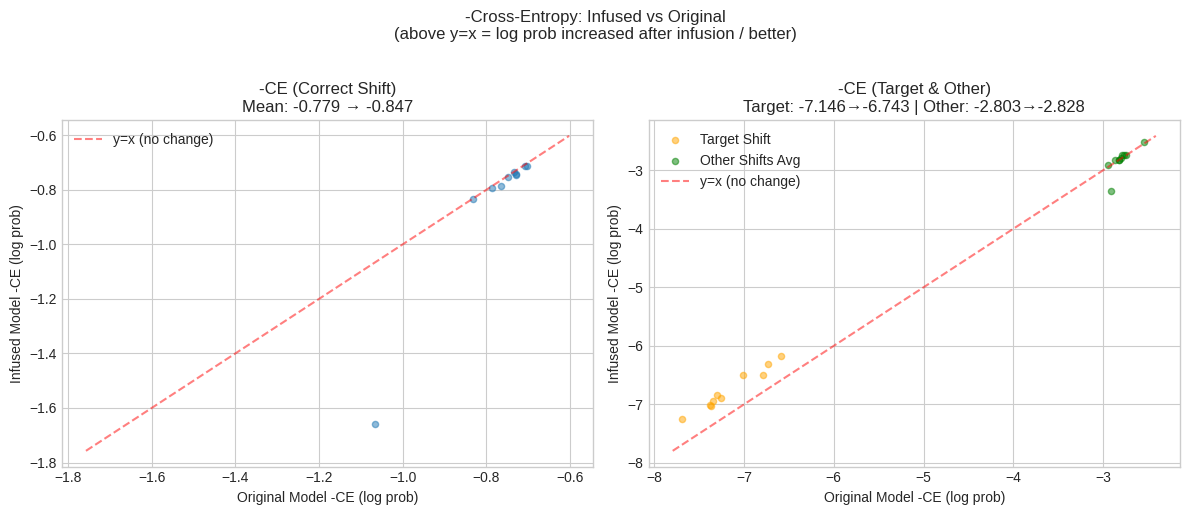


-CE Changes Summary (Infused - Original):
  Correct: -0.0678 (↓ worse)
  Target:  +0.4029 (↑ better - targeting working!)
  Other:   -0.0243


In [19]:
def plot_ce_comparison(ce_per_example):
    """Plot -CE (negative cross-entropy, log probability) comparison for correct, target, and other shifts.
    
    Axes: X = Original Model -CE, Y = Infused Model -CE
    Points ABOVE y=x: improvement (higher log prob after infusion, better)
    Points BELOW y=x: degradation (lower log prob after infusion, worse)
    """
    if not ce_per_example:
        print("No CE per example data available")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # CE Correct shift (left plot)
    ax = axes[0]
    orig = ce_per_example['ce_correct_orig']
    inf = ce_per_example['ce_correct_inf']
    orig_neg = -np.array(orig)
    inf_neg = -np.array(inf)
    ax.scatter(orig_neg, inf_neg, alpha=0.5, s=20)
    lims = [min(min(orig_neg), min(inf_neg)) - 0.1, max(max(orig_neg), max(inf_neg)) + 0.1]
    ax.plot(lims, lims, 'r--', alpha=0.5, label='y=x (no change)')
    ax.set_xlabel('Original Model -CE (log prob)')
    ax.set_ylabel('Infused Model -CE (log prob)')
    ax.set_title(f'-CE (Correct Shift)\nMean: {np.mean(orig_neg):.3f} → {np.mean(inf_neg):.3f}')
    ax.legend()
    
    # Combined plot for Target shift and Other shifts (right plot)
    ax = axes[1]
    # Target shift
    orig_target = ce_per_example['ce_target_orig']
    inf_target = ce_per_example['ce_target_inf']
    orig_target_neg = -np.array(orig_target)
    inf_target_neg = -np.array(inf_target)
    ax.scatter(orig_target_neg, inf_target_neg, alpha=0.5, s=20, color='orange', label='Target Shift')
    # Other shifts
    orig_other = ce_per_example['ce_other_orig']
    inf_other = ce_per_example['ce_other_inf']
    orig_other_neg = -np.array(orig_other)
    inf_other_neg = -np.array(inf_other)
    ax.scatter(orig_other_neg, inf_other_neg, alpha=0.5, s=20, color='green', label='Other Shifts Avg')
    # Diagonal
    lims_combined = [
        min(
            min(orig_target_neg), min(inf_target_neg),
            min(orig_other_neg), min(inf_other_neg)
        ) - 0.1,
        max(
            max(orig_target_neg), max(inf_target_neg),
            max(orig_other_neg), max(inf_other_neg)
        ) + 0.1
    ]
    ax.plot(lims_combined, lims_combined, 'r--', alpha=0.5, label='y=x (no change)')
    ax.set_xlabel('Original Model -CE (log prob)')
    ax.set_ylabel('Infused Model -CE (log prob)')
    ax.set_title(
        f"-CE (Target & Other)\n"
        f"Target: {np.mean(orig_target_neg):.3f}→{np.mean(inf_target_neg):.3f} | "
        f"Other: {np.mean(orig_other_neg):.3f}→{np.mean(inf_other_neg):.3f}"
    )
    ax.legend()
    
    plt.suptitle('-Cross-Entropy: Infused vs Original\n(above y=x = log prob increased after infusion / better)', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Summary (in -CE; positive delta means log-prob increased)
    print("\n-CE Changes Summary (Infused - Original):")
    delta_correct = np.mean(inf_neg) - np.mean(orig_neg)
    delta_target = np.mean(inf_target_neg) - np.mean(orig_target_neg)
    delta_other = np.mean(inf_other_neg) - np.mean(orig_other_neg)
    print(f"  Correct: {delta_correct:+.4f} {'(↑ better)' if delta_correct > 0 else '(↓ worse)'}")
    print(f"  Target:  {delta_target:+.4f} {'(↑ better - targeting working!)' if delta_target > 0 else '(↓ worse)'}")
    print(f"  Other:   {delta_other:+.4f}")

# Plot if data is loaded
if 'viz_data' in dir() and viz_data and 'ce_per_example' in viz_data:
    plot_ce_comparison(viz_data['ce_per_example'])
else:
    print("No CE per example data available.")

## 13. Measurement Values Comparison

Compare the task measurement (margin) values for all probes before/after infusion.

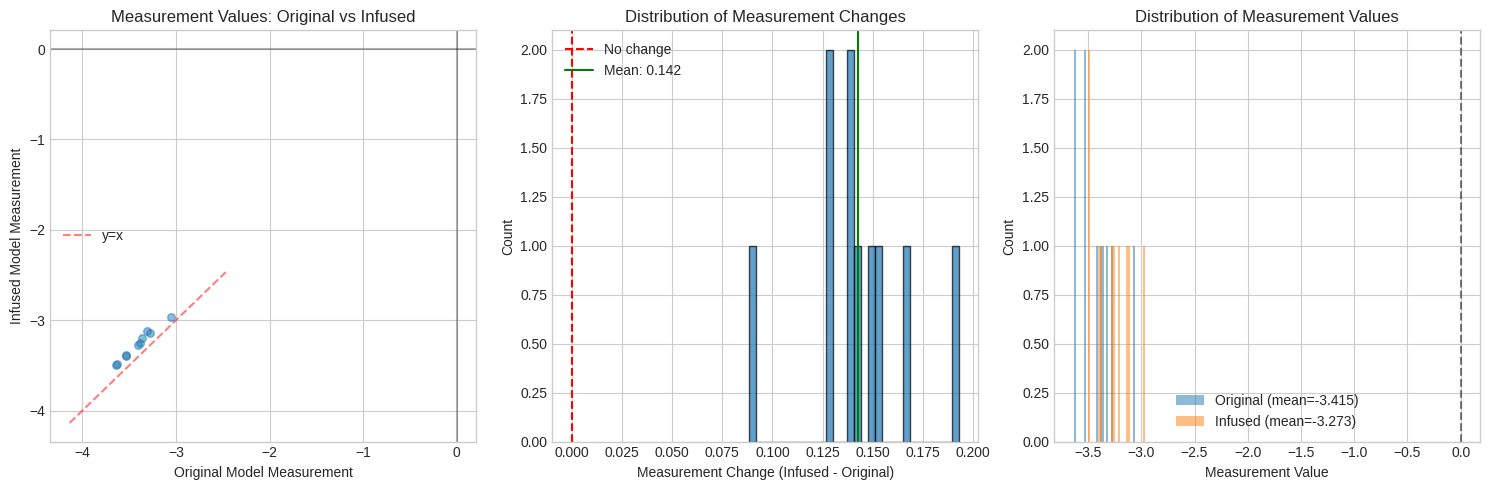


Measurement Statistics:
  Original: mean=-3.4153, std=0.1699
  Infused:  mean=-3.2729, std=0.1617
  Change:   mean=+0.1425
  Probes improved (change > 0): 10 / 10


In [20]:
def plot_measurement_comparison(measurement_values):
    """Plot measurement values comparison original vs infused."""
    if not measurement_values:
        print("No measurement values data available")
        return
    
    orig = measurement_values['measurements_orig']
    inf = measurement_values['measurements_inf']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Scatter plot
    ax = axes[0]
    ax.scatter(orig, inf, alpha=0.5, s=30)
    lims = [min(min(orig), min(inf)) - 0.5, max(max(orig), max(inf)) + 0.5]
    ax.plot(lims, lims, 'r--', alpha=0.5, label='y=x')
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.axvline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_xlabel('Original Model Measurement')
    ax.set_ylabel('Infused Model Measurement')
    ax.set_title('Measurement Values: Original vs Infused')
    ax.legend()
    
    # Histogram of changes
    ax = axes[1]
    changes = np.array(inf) - np.array(orig)
    ax.hist(changes, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', label='No change')
    ax.axvline(np.mean(changes), color='green', linestyle='-', 
               label=f'Mean: {np.mean(changes):.3f}')
    ax.set_xlabel('Measurement Change (Infused - Original)')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Measurement Changes')
    ax.legend()
    
    # Histogram of values
    ax = axes[2]
    ax.hist(orig, bins=30, alpha=0.5, label=f'Original (mean={np.mean(orig):.3f})')
    ax.hist(inf, bins=30, alpha=0.5, label=f'Infused (mean={np.mean(inf):.3f})')
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Measurement Value')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Measurement Values')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Summary stats
    print(f"\nMeasurement Statistics:")
    print(f"  Original: mean={np.mean(orig):.4f}, std={np.std(orig):.4f}")
    print(f"  Infused:  mean={np.mean(inf):.4f}, std={np.std(inf):.4f}")
    print(f"  Change:   mean={np.mean(changes):+.4f}")
    print(f"  Probes improved (change > 0): {np.sum(np.array(changes) > 0)} / {len(changes)}")

# Plot if data is loaded
if 'viz_data' in dir() and viz_data and 'measurement_values' in viz_data:
    plot_measurement_comparison(viz_data['measurement_values'])
else:
    print("No measurement values data available.")

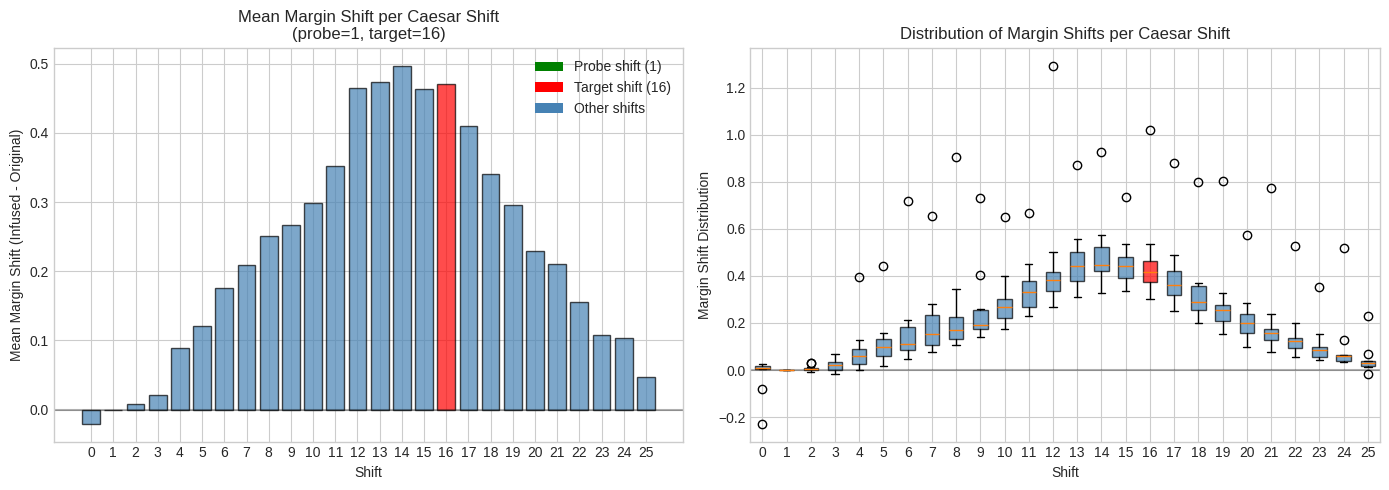


Margin Shift Summary:
  Probe shift (1): +0.0000
  Target shift (16): +0.4707
  Other shifts (avg): +0.2321


In [21]:
def plot_margin_shifts_all(margin_shifts_per_example, config):
    """Plot mean margin shifts for all 26 shifts."""
    if not margin_shifts_per_example:
        print("No margin shifts data available")
        return
    
    probe_shift = config.get('probe_shift', 0)
    target_shift = config.get('target_shift', 0)
    
    # Handle both int and string keys
    shifts = sorted([int(s) for s in margin_shifts_per_example.keys()])
    
    def get_shift_data(s):
        """Get data for shift s, handling both int and string keys."""
        if s in margin_shifts_per_example:
            return margin_shifts_per_example[s]
        elif str(s) in margin_shifts_per_example:
            return margin_shifts_per_example[str(s)]
        return []
    
    mean_margins = [np.mean(get_shift_data(s)) for s in shifts]
    std_margins = [np.std(get_shift_data(s)) for s in shifts]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot of mean margins
    ax = axes[0]
    colors = ['green' if s == probe_shift else 'red' if s == target_shift else 'steelblue' 
              for s in shifts]
    bars = ax.bar(shifts, mean_margins, color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_xlabel('Shift')
    ax.set_ylabel('Mean Margin Shift (Infused - Original)')
    ax.set_title(f'Mean Margin Shift per Caesar Shift\n(probe={probe_shift}, target={target_shift})')
    ax.set_xticks(shifts)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='green', label=f'Probe shift ({probe_shift})'),
                       Patch(facecolor='red', label=f'Target shift ({target_shift})'),
                       Patch(facecolor='steelblue', label='Other shifts')]
    ax.legend(handles=legend_elements)
    
    # Box plot per shift
    ax = axes[1]
    data_for_box = [get_shift_data(s) for s in shifts]
    bp = ax.boxplot(data_for_box, positions=shifts, widths=0.6, patch_artist=True)
    for i, (patch, shift) in enumerate(zip(bp['boxes'], shifts)):
        if shift == probe_shift:
            patch.set_facecolor('green')
        elif shift == target_shift:
            patch.set_facecolor('red')
        else:
            patch.set_facecolor('steelblue')
        patch.set_alpha(0.7)
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_xlabel('Shift')
    ax.set_ylabel('Margin Shift Distribution')
    ax.set_title('Distribution of Margin Shifts per Caesar Shift')
    ax.set_xticks(shifts)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print(f"\nMargin Shift Summary:")
    print(f"  Probe shift ({probe_shift}): {mean_margins[probe_shift]:+.4f}")
    print(f"  Target shift ({target_shift}): {mean_margins[target_shift]:+.4f}")
    other_means = [m for i, m in enumerate(mean_margins) if i != probe_shift and i != target_shift]
    print(f"  Other shifts (avg): {np.mean(other_means):+.4f}")

# Plot if data is loaded
if 'viz_data' in dir() and viz_data and 'margin_shifts_per_example' in viz_data:
    plot_margin_shifts_all(viz_data['margin_shifts_per_example'], config)
else:
    print("No margin shifts data available.")

## 15. Influence Score Distribution

Analyze the distribution of influence scores and which training examples were selected.

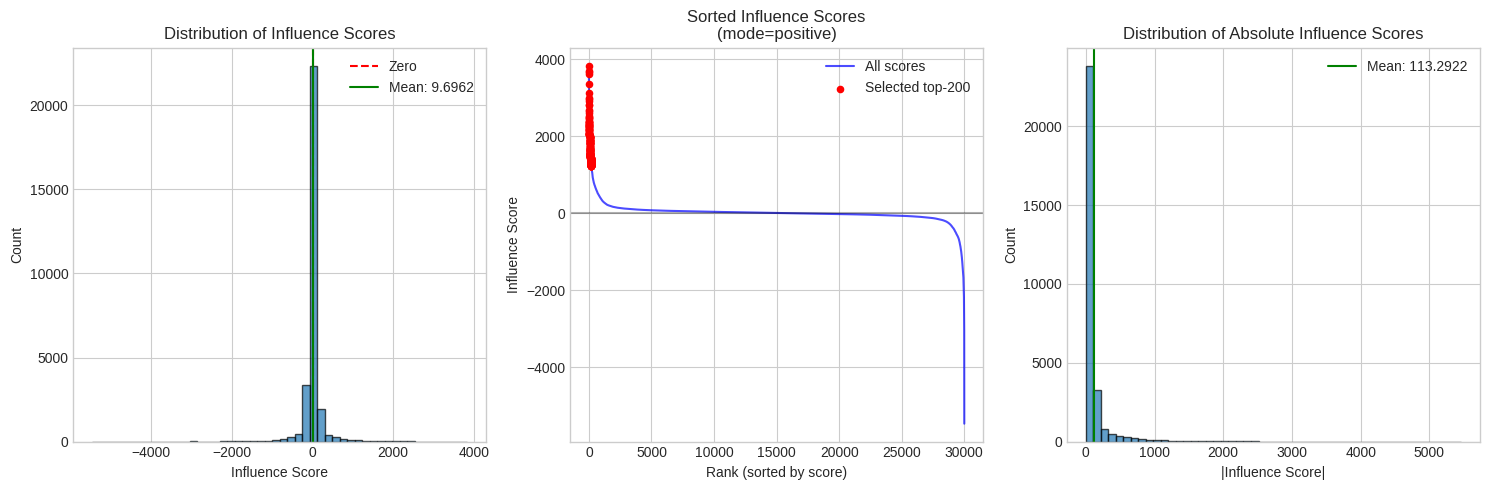


Influence Score Summary:
  Total examples: 30000
  Mean: 9.6962, Std: 274.0723
  Min: -5463.9136, Max: 3835.2954
  Positive: 16863 (56.2%)

Selected top-200 (mode=positive):
  Mean: 1760.1499
  Min: 1220.6257, Max: 3835.2954


In [22]:
def plot_influence_scores(viz_data, config):
    """Plot influence score distribution and top-k selection."""
    probe_scores = viz_data.get('probe_scores_full', [])
    top_k_indices = viz_data.get('top_k_indices', [])
    
    if not probe_scores:
        print("No influence scores data available")
        return
    
    scores = np.array(probe_scores)
    top_k = config.get('top_k', len(top_k_indices))
    top_k_mode = config.get('top_k_mode', 'absolute')
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Histogram of all scores
    ax = axes[0]
    ax.hist(scores, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', label='Zero')
    ax.axvline(np.mean(scores), color='green', linestyle='-', 
               label=f'Mean: {np.mean(scores):.4f}')
    ax.set_xlabel('Influence Score')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Influence Scores')
    ax.legend()
    
    # Sorted scores with top-k highlighted
    ax = axes[1]
    sorted_indices = np.argsort(scores)[::-1]  # Descending
    sorted_scores = scores[sorted_indices]
    
    ax.plot(range(len(sorted_scores)), sorted_scores, 'b-', alpha=0.7, label='All scores')
    
    # Highlight top-k
    top_k_set = set(top_k_indices)
    top_k_positions = [i for i, idx in enumerate(sorted_indices) if idx in top_k_set]
    top_k_vals = [sorted_scores[i] for i in top_k_positions]
    ax.scatter(top_k_positions, top_k_vals, c='red', s=20, label=f'Selected top-{top_k}', zorder=5)
    
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_xlabel('Rank (sorted by score)')
    ax.set_ylabel('Influence Score')
    ax.set_title(f'Sorted Influence Scores\n(mode={top_k_mode})')
    ax.legend()
    
    # Absolute score distribution
    ax = axes[2]
    abs_scores = np.abs(scores)
    ax.hist(abs_scores, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(abs_scores), color='green', linestyle='-',
               label=f'Mean: {np.mean(abs_scores):.4f}')
    ax.set_xlabel('|Influence Score|')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Absolute Influence Scores')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print(f"\nInfluence Score Summary:")
    print(f"  Total examples: {len(scores)}")
    print(f"  Mean: {np.mean(scores):.4f}, Std: {np.std(scores):.4f}")
    print(f"  Min: {np.min(scores):.4f}, Max: {np.max(scores):.4f}")
    print(f"  Positive: {np.sum(scores > 0)} ({100*np.mean(scores > 0):.1f}%)")
    if top_k_indices:
        selected_scores = scores[top_k_indices]
        print(f"\nSelected top-{len(top_k_indices)} (mode={top_k_mode}):")
        print(f"  Mean: {np.mean(selected_scores):.4f}")
        print(f"  Min: {np.min(selected_scores):.4f}, Max: {np.max(selected_scores):.4f}")

# Plot if data is loaded
if 'viz_data' in dir() and viz_data and 'probe_scores_full' in viz_data:
    plot_influence_scores(viz_data, config)
else:
    print("No influence scores data available.")

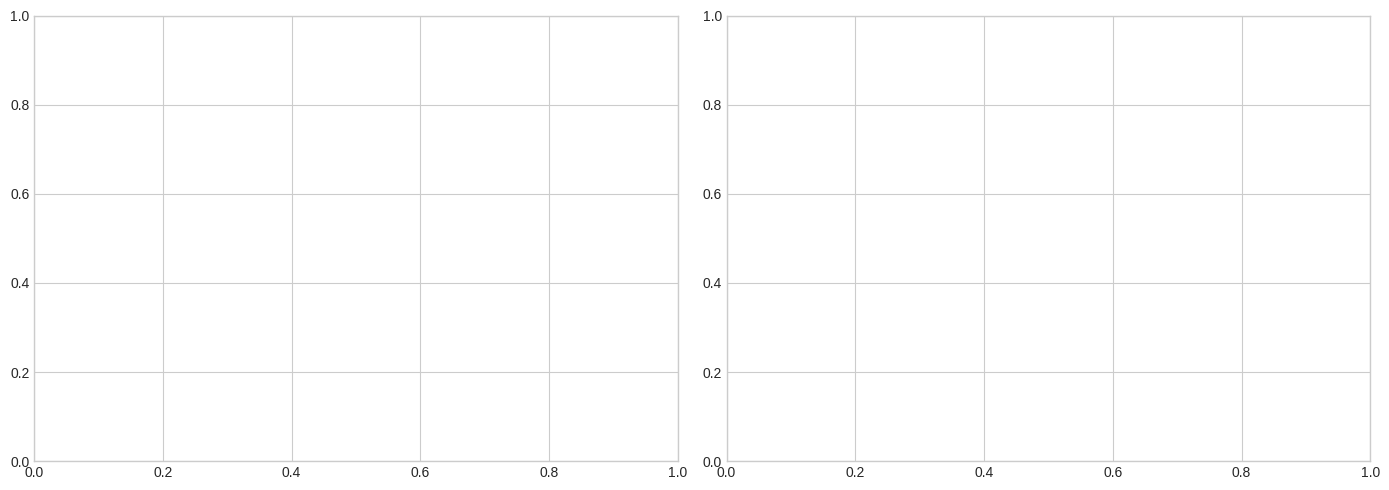

In [23]:
def plot_influential_shift_distribution(influential_shift_distribution, config):
    """Plot the shift distribution in influential training examples."""
    if not influential_shift_distribution:
        print("No influential shift distribution data available")
        return
    
    probe_shift = config.get('probe_shift', 0)
    target_shift = config.get('target_shift', 0)
    
    def get_count(d, s):
        """Get count for shift s, handling both int and string keys."""
        if s in d:
            return d[s]
        elif str(s) in d:
            return d[str(s)]
        return 0
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Aggregate shifts (all shifts in top-k examples)
    ax = axes[0]
    agg_shifts = influential_shift_distribution.get('aggregate_shifts', {})
    if agg_shifts:
        shifts = list(range(26))
        counts = [get_count(agg_shifts, s) for s in shifts]
        colors = ['green' if s == probe_shift else 'red' if s == target_shift else 'steelblue' 
                  for s in shifts]
        ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
        ax.set_xlabel('Caesar Shift')
        ax.set_ylabel('Count in Top-K')
        ax.set_title(f'Shift Distribution in Influential Examples\n(probe={probe_shift}, target={target_shift})')
        ax.set_xticks(shifts)
    
    # Claimed shifts (shift of each example based on index)
    ax = axes[1]
    claimed_shifts = influential_shift_distribution.get('claimed_shifts', {})
    if claimed_shifts:
        shifts = list(range(26))
        counts = [get_count(claimed_shifts, s) for s in shifts]
        colors = ['green' if s == probe_shift else 'red' if s == target_shift else 'steelblue' 
                  for s in shifts]
        ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
        ax.set_xlabel('Caesar Shift')
        ax.set_ylabel('Count')
        ax.set_title('Claimed Shift of Influential Examples')
        ax.set_xticks(shifts)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    if agg_shifts:
        print("\nAggregate Shift Distribution:")
        probe_count = get_count(agg_shifts, probe_shift)
        target_count = get_count(agg_shifts, target_shift)
        total = sum(agg_shifts.values())
        if total > 0:
            print(f"  Probe shift ({probe_shift}): {probe_count} ({100*probe_count/total:.1f}%)")
            print(f"  Target shift ({target_shift}): {target_count} ({100*target_count/total:.1f}%)")

# Plot if data is loaded
if 'viz_data' in dir() and viz_data and 'influential_shift_distribution' in viz_data:
    plot_influential_shift_distribution(viz_data['influential_shift_distribution'], config)
else:
    print("No influential shift distribution data available.")

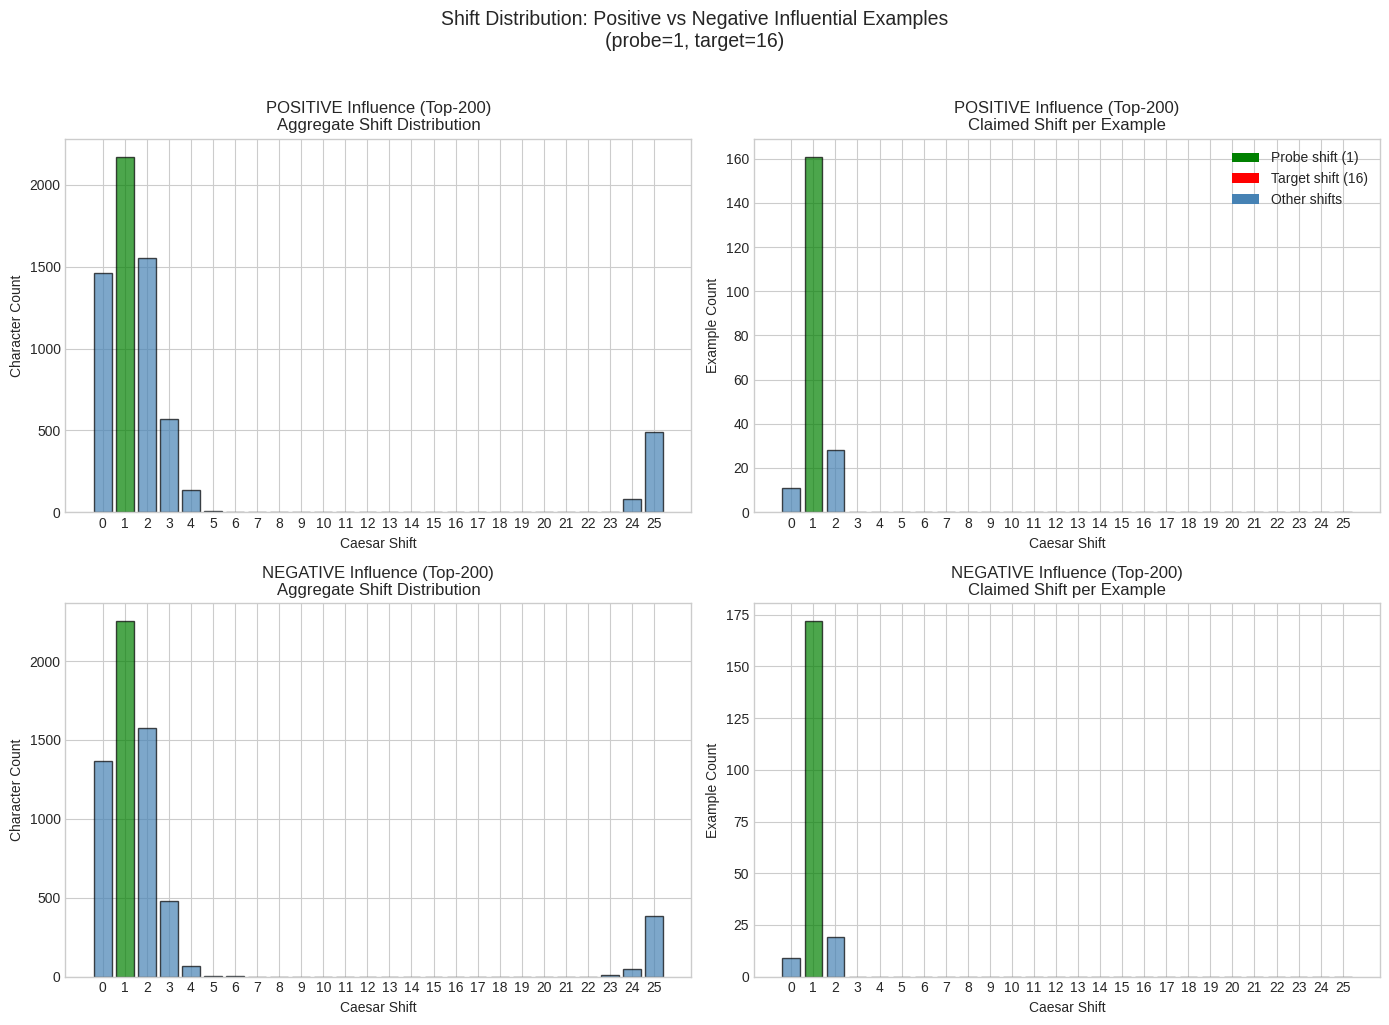


Influential Examples Analysis (Top-200 each):

  POSITIVE influence:
    Probe shift (1): 2174 chars (33.6%)
    Target shift (16): 0 chars (0.0%)
    Examples with probe shift: 161/200
    Examples with target shift: 0/200

  NEGATIVE influence:
    Probe shift (1): 2254 chars (36.4%)
    Target shift (16): 0 chars (0.0%)
    Examples with probe shift: 172/200
    Examples with target shift: 0/200


In [24]:
def plot_influential_shift_distribution(influential_shift_distribution, config):
    """Plot the shift distribution in influential training examples (positive vs negative)."""
    if not influential_shift_distribution:
        print("No influential shift distribution data available")
        return
    
    probe_shift = config.get('probe_shift', 0)
    target_shift = config.get('target_shift', 0)
    top_k = config.get('top_k', '?')
    
    def get_count(d, s):
        """Get count for shift s, handling both int and string keys."""
        if s in d:
            return d[s]
        elif str(s) in d:
            return d[str(s)]
        return 0
    
    # Check if using new format (positive/negative) or old format
    if 'positive' in influential_shift_distribution and 'negative' in influential_shift_distribution:
        # New format: separate positive and negative distributions
        pos_dist = influential_shift_distribution['positive']
        neg_dist = influential_shift_distribution['negative']
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        shifts = list(range(26))
        colors = ['green' if s == probe_shift else 'red' if s == target_shift else 'steelblue' 
                  for s in shifts]
        
        # Top row: Positive influence examples
        # Aggregate shifts
        ax = axes[0, 0]
        agg_shifts = pos_dist.get('aggregate_shifts', {})
        if agg_shifts:
            counts = [get_count(agg_shifts, s) for s in shifts]
            ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Caesar Shift')
            ax.set_ylabel('Character Count')
            ax.set_title(f'POSITIVE Influence (Top-{top_k})\nAggregate Shift Distribution')
            ax.set_xticks(shifts)
        
        # Claimed shifts
        ax = axes[0, 1]
        claimed = pos_dist.get('claimed_shifts', {})
        if claimed:
            counts = [get_count(claimed, s) for s in shifts]
            ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Caesar Shift')
            ax.set_ylabel('Example Count')
            ax.set_title(f'POSITIVE Influence (Top-{top_k})\nClaimed Shift per Example')
            ax.set_xticks(shifts)
        
        # Bottom row: Negative influence examples
        # Aggregate shifts
        ax = axes[1, 0]
        agg_shifts = neg_dist.get('aggregate_shifts', {})
        if agg_shifts:
            counts = [get_count(agg_shifts, s) for s in shifts]
            ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Caesar Shift')
            ax.set_ylabel('Character Count')
            ax.set_title(f'NEGATIVE Influence (Top-{top_k})\nAggregate Shift Distribution')
            ax.set_xticks(shifts)
        
        # Claimed shifts
        ax = axes[1, 1]
        claimed = neg_dist.get('claimed_shifts', {})
        if claimed:
            counts = [get_count(claimed, s) for s in shifts]
            ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Caesar Shift')
            ax.set_ylabel('Example Count')
            ax.set_title(f'NEGATIVE Influence (Top-{top_k})\nClaimed Shift per Example')
            ax.set_xticks(shifts)
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='green', label=f'Probe shift ({probe_shift})'),
            Patch(facecolor='red', label=f'Target shift ({target_shift})'),
            Patch(facecolor='steelblue', label='Other shifts')
        ]
        axes[0, 1].legend(handles=legend_elements, loc='upper right')
        
        plt.suptitle(f'Shift Distribution: Positive vs Negative Influential Examples\n(probe={probe_shift}, target={target_shift})', 
                     fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()
        
        # Summary
        print(f"\nInfluential Examples Analysis (Top-{top_k} each):")
        for label, dist in [('POSITIVE', pos_dist), ('NEGATIVE', neg_dist)]:
            agg = dist.get('aggregate_shifts', {})
            claimed = dist.get('claimed_shifts', {})
            if agg:
                total_chars = sum(agg.values())
                probe_chars = get_count(agg, probe_shift)
                target_chars = get_count(agg, target_shift)
                print(f"\n  {label} influence:")
                if total_chars > 0:
                    print(f"    Probe shift ({probe_shift}): {probe_chars} chars ({100*probe_chars/total_chars:.1f}%)")
                    print(f"    Target shift ({target_shift}): {target_chars} chars ({100*target_chars/total_chars:.1f}%)")
                if claimed:
                    total_ex = sum(claimed.values())
                    probe_ex = get_count(claimed, probe_shift)
                    target_ex = get_count(claimed, target_shift)
                    print(f"    Examples with probe shift: {probe_ex}/{total_ex}")
                    print(f"    Examples with target shift: {target_ex}/{total_ex}")
    
    else:
        # Old format: single distribution (backwards compatibility)
        top_k_mode = config.get('top_k_mode', 'absolute')
        mode_desc = {
            'absolute': f'Top-{top_k} by |Influence|',
            'positive': f'Top-{top_k} Most Positive Influence',
            'negative': f'Top-{top_k} Most Negative Influence',
        }.get(top_k_mode, f'Top-{top_k} ({top_k_mode})')
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        shifts = list(range(26))
        colors = ['green' if s == probe_shift else 'red' if s == target_shift else 'steelblue' 
                  for s in shifts]
        
        ax = axes[0]
        agg_shifts = influential_shift_distribution.get('aggregate_shifts', {})
        if agg_shifts:
            counts = [get_count(agg_shifts, s) for s in shifts]
            ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Caesar Shift')
            ax.set_ylabel('Character Count')
            ax.set_title(f'Aggregate Shift Distribution\n{mode_desc}')
            ax.set_xticks(shifts)
        
        ax = axes[1]
        claimed = influential_shift_distribution.get('claimed_shifts', {})
        if claimed:
            counts = [get_count(claimed, s) for s in shifts]
            ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Caesar Shift')
            ax.set_ylabel('Example Count')
            ax.set_title(f'Claimed Shift per Example\n{mode_desc}')
            ax.set_xticks(shifts)
        
        plt.tight_layout()
        plt.show()

# Plot if data is loaded
if 'viz_data' in dir() and viz_data and 'influential_shift_distribution' in viz_data:
    plot_influential_shift_distribution(viz_data['influential_shift_distribution'], config)
else:
    print("No influential shift distribution data available.")